#CAM7 – Mean Climate from Climo Files

Reads pre-computed climo files from `/glade/derecho/scratch/rneale/archive/<run>/climo/` and plots the **time-mean** field for each case.

Climo file naming: `<case>_<TAG>_climo.nc` where TAG is `ANN`, `DJF|MAM|JJA|SON`, or `01`..`12`.

Cases are defined in `dcases` (label → run name).  
Optional filters: SEASON (picks which climo file to read) and lat/lon region.  
Maps display 0–360° longitude.

In [1]:
import warnings
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from pathlib import Path
from collections import OrderedDict
from IPython.display import Image, display as ipy_display

# ── Shapely 2.x / cartopy compatibility fix ─────────────────────────────
from shapely.geometry.base import BaseMultipartGeometry
if not hasattr(BaseMultipartGeometry, '__getitem__'):
    BaseMultipartGeometry.__getitem__ = lambda self, i: self.geoms[i]
# ──────────────────────────────────────────────────────────────────────

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'font.size': 10})

In [83]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [84]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",   
    cores=4,
    memory="32GB",
    processes=4,      # one process per core (safe default)cesm2
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)

cluster.scale(jobs=32)
client = Client(cluster)

client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc51.hpc.ucar.edu/47205/proxy/44725/status,
Dashboard: /node/crhtc51.hpc.ucar.edu/47205/proxy/44725/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.101:46767,Workers: 0
Dashboard: /node/crhtc51.hpc.ucar.edu/47205/proxy/44725/status,Total threads: 0
Started: Just now,Total memory: 0 B


---
## Options

In [85]:
# ══════════════════════════════════════════════════════════════════════
#  Consolidated options for all sections of this notebook
# ══════════════════════════════════════════════════════════════════════

# ── Paths ─────────────────────────────────────────────────────────────
ARCHIVE_DIR   = Path('/glade/derecho/scratch/rneale/archive')
OBS_CLIMO_DIR = Path('/glade/campaign/cgd/amp/amwg/amwg_data/obs_data')
ERA5_ROOT     = Path('/glade/derecho/scratch/rneale/ERA5/mmean/1deg')
DIR_FIG       = Path('/glade/u/home/rneale/python/python-figs/papers/ZM_PBL')

# ── Cases (label → archive run name; each must have <run>/climo/*.nc) ─
dcases = {
    'C7-L58' : 'f.e30.FLTHIST.CAM7.L58.000a',
    'C7-L48' : 'f.e30.FLTHIST.CAM7.L48.000a',
    'C7-L32' : 'f.e30.FLTHIST.CAM7.L32.000a',
    'C7-noZMP-L58' : 'f.e30.FLTHIST.CAM7.L58.001a',
    'C7-noZMP-L48' : 'f.e30.FLTHIST.CAM7.L48.001a',
    'C7-noZMP-L32' : 'f.e30.FLTHIST.CAM7.L32.001a',
    'C7-C6-L32' : 'f.e30.FHIST.CAM6-phys.L32.000a',
    'C6-L32' : 'f.e22.FHIST.f09_f09.CAM6.L32.000',
}
CASES       = list(dcases.values())
CASE_LABELS = list(dcases.keys())

# Group physics with color, distinguish vertical resolution with linestyle.
#   blue  = CAM7 default ZM   (000a series)
#   red   = CAM7 no-ZM-parcel (001a series)
#   green = CAM6-physics baselines
CASE_COLORS = {
    'C7-L58'       : '#4477AA',
    'C7-L48'       : '#4477AA',
    'C7-L32'       : '#4477AA',
    'C7-noZMP-L58' : '#EE6677',
    'C7-noZMP-L48' : '#EE6677',
    'C7-noZMP-L32' : '#EE6677',
    'C7-C6-L32'    : '#228833',
    'C6-L32'       : '#228833',
}
CASE_LINESTYLES = {
    'C7-L58'       : '-',
    'C7-L48'       : '--',
    'C7-L32'       : ':',
    'C7-noZMP-L58' : '-',
    'C7-noZMP-L48' : '--',
    'C7-noZMP-L32' : ':',
    'C7-C6-L32'    : '-',
    'C6-L32'       : '--',
}

# ── Season / period ───────────────────────────────────────────────────
# 'ANN', 'DJF', 'MAM', 'JJA', 'SON', or a two-digit month string '01'..'12'
SEASON = 'DJF'

# ── Region for map/bias plots ─────────────────────────────────────────
LAT_BOUNDS = (-20., 20.)         # (lat_min, lat_max); None = global
LON_BOUNDS = (0., 360.)          # (lon_min, lon_max); None = global

# ── Zonal cross-section (line plot averaged over these longitudes;
#     also drawn as dotted delimiters on all lat/lon maps) ─────────────
ZONAL_LON_BOUNDS = (160., 190.)  # None disables

# ── Vertical profile options ──────────────────────────────────────────
PROFILE_LAT_BOUNDS = (-20., 0.)
PROFILE_LON_BOUNDS = (160., 190.)
ERA5_YEAR_RANGE    = (1979, 2005)   # inclusive
PROFILE_SEASON     = None            # None → use SEASON above
# False → interp each CAM column onto PROFILE_PLEV, then area-average
#         (common grid; directly comparable across cases and to ERA5)
# True  → area-average variable and PMID at each native hybrid mid-level
#         (each case appears on its own vertical grid)
PROFILE_USE_NATIVE_LEVELS = True
PROFILE_PLEV = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 70, 50, 30, 20]

# Optional PRECT-based sampling: only average columns whose climo PRECT
# exceeds this threshold (mm/day).  Set to None to just use the lat/lon box.
# The lat/lon box is always applied first — the threshold further narrows
# it down.  Each case uses its OWN PRECT climatology to build the mask
# (CAM PRECT for cases, ERA5 tp for ERA5).
PROFILE_PRECT_THRESHOLD = 1.0       # e.g. 2.0 → columns with PRECT > 2 mm/day

CP = 1004.   # used to convert STEND_CLUBB (J/kg/s) → K/day

# ── Variable configuration for map / bias / zonal plots ───────────────
VAR_CONFIG = {
    'PRECT':    {'scale': 86400*1000, 'units': 'mm day⁻¹',    'cmap': 'terrain_r', 'lev': None},
#    'PRECC':    {'scale': 86400*1000, 'units': 'mm day⁻¹',    'cmap': 'Blues',     'lev': None},
#    'SWCF':     {'scale': 1.,         'units': 'W m⁻²',        'cmap': 'RdBu',      'lev': None},
#    'CAPE':     {'scale': 1,          'units': 'J kg⁻¹',       'cmap': 'YlOrRd',    'lev': None},
#    'FLUT':     {'scale': 1,          'units': 'W m⁻²',        'cmap': 'hot_r',     'lev': None},
#    'ZMDT':     {'scale': 86400,      'units': 'K day⁻¹',      'cmap': 'RdBu_r',    'lev': 850},
}

# ── Obs climo sources (per variable) ──────────────────────────────────
# Each entry: label -> {'prefix', 'var', 'scale', 'dir' (optional Path),
# 'pattern' (optional filename template using {prefix} and {season};
#            defaults to '{prefix}_{season}_climo.nc')}
OBS_CLIMO = {
    'PRECT': OrderedDict([
#        ('GPCP',  {'prefix': 'GPCP',  'var': 'PRECT',  'scale': 1.}),
        ('IMERG', {'prefix': 'IMERG', 'var': 'precip', 'scale': 1.,
                   'dir': Path('/glade/work/rneale/data/IMERG'),
                   'pattern': '{prefix}_climo_{season}.nc'}),
        ('GPCP',  {'prefix': 'GPCP',  'var': 'PRECT',  'scale': 1.}),
    ]),
}

# ── Variable configuration for vertical profile plots ─────────────────
# CAM_var: {era5_dir, era5_var, scale (applied to both CAM & ERA5), units}
# Set era5_dir=None for CAM-only variables (no ERA5 counterpart).
PROFILE_VARS = {
    'T':             {'era5_dir': 't',     'era5_var': 't',  'scale': 1.,             'units': 'K'},
    'Q':             {'era5_dir': 'q',     'era5_var': 'q',  'scale': 1000.,          'units': 'g kg⁻¹'},
    'U':             {'era5_dir': 'u',     'era5_var': 'u',  'scale': 1.,             'units': 'm s⁻¹'},
    'V':             {'era5_dir': 'v',     'era5_var': 'v',  'scale': 1.,             'units': 'm s⁻¹'},
    'OMEGA':         {'era5_dir': 'omega', 'era5_var': 'w',  'scale': 864.,           'units': 'hPa day⁻¹'},
    'RELHUM':        {'era5_dir': 'rh',    'era5_var': 'r',  'scale': 1.,             'units': '%'},
    'CLOUD':         {'era5_dir': 'cloud', 'era5_var': 'cc', 'scale': 100.,           'units': '%'},
    # ── Tendencies (CAM-only) ──
    'ZMDT':          {'era5_dir': None, 'era5_var': None,    'scale': 86400.,         'units': 'K day⁻¹'},
    'ZMDQ':          {'era5_dir': None, 'era5_var': None,    'scale': 86400.*1000.,   'units': 'g kg⁻¹ day⁻¹'},
    'STEND_CLUBB':   {'era5_dir': None, 'era5_var': None,    'scale': 86400./CP,      'units': 'K day⁻¹'},
    'RVMTEND_CLUBB': {'era5_dir': None, 'era5_var': None,    'scale': 86400.*1000.,   'units': 'g kg⁻¹ day⁻¹'},
}

# ── Variables to process in each section ──────────────────────────────
VARS_TO_PLOT         = ['PRECT']                                        # maps / bias / zonal
PROFILE_VARS_TO_PLOT = ['T', 'Q', 'U', 'OMEGA',
                        'ZMDT', 'ZMDQ', 'STEND_CLUBB', 'RVMTEND_CLUBB']  # vertical profiles

# ── Summary ───────────────────────────────────────────────────────────
print('Cases:', CASE_LABELS)
print(f'Season/tag: {SEASON}   Lat: {LAT_BOUNDS or "global"}   Lon: {LON_BOUNDS or "global"}')
print(f'Zonal section lon: {ZONAL_LON_BOUNDS or "disabled"}')
_grid_str = 'native hybrid mid-levels' if PROFILE_USE_NATIVE_LEVELS else f'target plev={PROFILE_PLEV}'
_mask_str = f'PRECT > {PROFILE_PRECT_THRESHOLD} mm/day (mask)' if PROFILE_PRECT_THRESHOLD else 'lat/lon box only'
print(f'Profile region:   lat {PROFILE_LAT_BOUNDS}   lon {PROFILE_LON_BOUNDS}   sample: {_mask_str}')
print(f'ERA5 years:       {ERA5_YEAR_RANGE[0]}–{ERA5_YEAR_RANGE[1]}   season: {PROFILE_SEASON or SEASON}')
print(f'CAM vert grid:    {_grid_str}')
print('Map/zonal vars:  ', VARS_TO_PLOT)
print('Profile vars:    ', PROFILE_VARS_TO_PLOT)

Cases: ['C7-L58', 'C7-L48', 'C7-L32', 'C7-noZMP-L58', 'C7-noZMP-L48', 'C7-noZMP-L32', 'C7-C6-L32', 'C6-L32']
Season/tag: DJF   Lat: (-20.0, 20.0)   Lon: (0.0, 360.0)
Zonal section lon: (160.0, 190.0)
Profile region:   lat (-20.0, 0.0)   lon (160.0, 190.0)   sample: PRECT > 1.0 mm/day (mask)
ERA5 years:       1979–2005   season: DJF
CAM vert grid:    native hybrid mid-levels
Map/zonal vars:   ['PRECT']
Profile vars:     ['T', 'Q', 'U', 'OMEGA', 'ZMDT', 'ZMDQ', 'STEND_CLUBB', 'RVMTEND_CLUBB']


---
## Helper functions

In [86]:
def climo_file(case, tag):
    """Path to the climo file for one case and season/month tag."""
    return ARCHIVE_DIR / case / 'climo' / f'{case}_{tag}_climo.nc'


def _region_slice(da):
    """Apply LAT_BOUNDS/LON_BOUNDS to a lat/lon DataArray."""
    if LAT_BOUNDS is not None:
        lat0, lat1 = min(LAT_BOUNDS), max(LAT_BOUNDS)
        da = da.where((da.lat >= lat0) & (da.lat <= lat1), drop=True)
    if LON_BOUNDS is not None:
        lon0, lon1 = LON_BOUNDS
        if lon0 < 0 and da.lon.values.min() >= 0:
            lon0, lon1 = lon0 + 360, lon1 + 360
        da = da.where((da.lon >= lon0) & (da.lon <= lon1), drop=True)
    return da


# ── Line-plot styling ────────────────────────────────────────────────
# Single helper used by every line plot in this notebook (zonal section,
# vertical profiles) so a case has consistent color + linestyle across
# figures.  Color is set by CASE_COLORS, linestyle by CASE_LINESTYLES.
def _line_style(label, is_obs=False, obs_marker='x'):
    """Return matplotlib.plot kwargs for either an obs reference or a CAM case."""
    if is_obs:
        return dict(color='black', linewidth=1.5, linestyle='-',
                    marker=obs_marker, markersize=6, markerfacecolor='none')
    return dict(color=CASE_COLORS.get(label),
                linestyle=CASE_LINESTYLES.get(label, '-'),
                linewidth=1.5)


# ── Colormap utilities ───────────────────────────────────────────────
def make_white_cmap(cmap_name, white_frac=0.08):
    """Return a copy of cmap_name with the lowest white_frac set to pure white."""
    base  = plt.get_cmap(cmap_name)
    rgba  = base(np.linspace(0, 1, 256))
    n     = max(1, int(256 * white_frac))
    rgba[:n] = [1., 1., 1., 1.]
    return mcolors.LinearSegmentedColormap.from_list(f'{cmap_name}_w0', rgba)

PRECIP_BLUES = make_white_cmap('Blues',  0.06)
PRECIP_GNBU  = make_white_cmap('GnBu',   0.06)
PRECIP_YG_W  = make_white_cmap('YlGnBu', 0.10)


def _compute_clim(arrays, base_cmap):
    """Robust (0, p98)-style color limits for the Mean across all datasets."""
    all_vals = np.concatenate([a.values.ravel() for a in arrays if a is not None])
    all_vals = all_vals[np.isfinite(all_vals)]
    if len(all_vals) == 0:
        return -1., 1., 'RdBu_r'
    if base_cmap == 'RdBu_r':
        v = np.nanpercentile(np.abs(all_vals), 98)
        return -v, v, 'RdBu_r'
    v = np.nanpercentile(np.abs(all_vals), 98)
    return 0., v, base_cmap


print('Helper functions defined.')
print('Colormap options: PRECIP_BLUES, PRECIP_GNBU, PRECIP_YG_W (or any matplotlib name)')

Helper functions defined.
Colormap options: PRECIP_BLUES, PRECIP_GNBU, PRECIP_YG_W (or any matplotlib name)


---
## Load climo means

Reads one climo file per case (season-tagged) and stores the field in `all_means[vname][case_label]`.

In [87]:
# all_means[vname][case_label] = DataArray(lat, lon)
all_means = {v: {} for v in VARS_TO_PLOT}

for vname in VARS_TO_PLOT:
    cfg   = VAR_CONFIG[vname]
    scale = cfg['scale']
    lev_p = cfg['lev']
    lev_info = f'@ {lev_p} hPa (nearest)' if lev_p else '2D surface field'
    print(f'\n── {vname}  ({lev_info})  tag={SEASON} ─────────────────────────')

    for case, label in zip(CASES, CASE_LABELS):
        fpath = climo_file(case, SEASON)
        if not fpath.exists():
            print(f'  {label}: missing {fpath.name} — skipping')
            all_means[vname][label] = None
            continue

        ds = xr.open_dataset(fpath)
        if vname not in ds.variables:
            print(f'  {label}: variable {vname!r} not in file — skipping')
            ds.close()
            all_means[vname][label] = None
            continue

        da = ds[vname] * scale
        if 'time' in da.dims:
            da = da.isel(time=0)
        if lev_p is not None and 'lev' in da.dims:
            da = da.sel(lev=lev_p, method='nearest')
        da = _region_slice(da).load()
        all_means[vname][label] = da
        ds.close()

        mean_val = float(da.mean())
        print(f'  {label}: global mean = {mean_val:.3g} {cfg["units"]}   ({fpath.name})')

print('\nDone.')


── PRECT  (2D surface field)  tag=DJF ─────────────────────────
  C7-L58: global mean = 4.42 mm day⁻¹   (f.e30.FLTHIST.CAM7.L58.000a_DJF_climo.nc)
  C7-L48: global mean = 4.35 mm day⁻¹   (f.e30.FLTHIST.CAM7.L48.000a_DJF_climo.nc)
  C7-L32: global mean = 4.34 mm day⁻¹   (f.e30.FLTHIST.CAM7.L32.000a_DJF_climo.nc)
  C7-noZMP-L58: global mean = 4.24 mm day⁻¹   (f.e30.FLTHIST.CAM7.L58.001a_DJF_climo.nc)
  C7-noZMP-L48: global mean = 4.23 mm day⁻¹   (f.e30.FLTHIST.CAM7.L48.001a_DJF_climo.nc)
  C7-noZMP-L32: global mean = 4.21 mm day⁻¹   (f.e30.FLTHIST.CAM7.L32.001a_DJF_climo.nc)
  C7-C6-L32: global mean = 4.16 mm day⁻¹   (f.e30.FHIST.CAM6-phys.L32.000a_DJF_climo.nc)
  C6-L32: global mean = 4.22 mm day⁻¹   (f.e22.FHIST.f09_f09.CAM6.L32.000_DJF_climo.nc)

Done.


---
## Load obs climo means

Reads one AMWG obs climo file per obs source and stores the field in `obs_means[vname][obs_label]`.

In [88]:
# obs_means[vname][obs_label] = DataArray(lat, lon)
obs_means = {v: {} for v in VARS_TO_PLOT}

for vname in VARS_TO_PLOT:
    if vname not in OBS_CLIMO:
        continue
    print(f'\n── {vname} obs  tag={SEASON} ─────────────────────────')

    for obs_label, spec in OBS_CLIMO[vname].items():
        obs_dir = spec.get('dir', OBS_CLIMO_DIR)
        pattern = spec.get('pattern', '{prefix}_{season}_climo.nc')
        fname   = pattern.format(prefix=spec.get('prefix', obs_label), season=SEASON)
        fpath   = obs_dir / fname
        if not fpath.exists():
            print(f'  {obs_label}: missing {fpath} — skipping')
            obs_means[vname][obs_label] = None
            continue

        # AMWG obs climos carry a 'julday' variable with units
        # 'days since January 1, 4713 B.C.' that xarray cannot decode.
        # We don't need calendar-aware time here (just isel(time=0)),
        # so open with decode_times=False.
        ds = xr.open_dataset(fpath, decode_times=False)
        obs_var = spec['var']
        if obs_var not in ds.variables:
            print(f'  {obs_label}: variable {obs_var!r} not in file — skipping')
            ds.close()
            obs_means[vname][obs_label] = None
            continue

        da = ds[obs_var] * spec['scale']
        if 'time' in da.dims:
            da = da.isel(time=0)
        # wrap to 0..360 if file uses -180..180
        if float(da.lon.values.min()) < 0:
            da = da.assign_coords(lon=(da.lon.values % 360)).sortby('lon')
        da = _region_slice(da).load()
        obs_means[vname][obs_label] = da
        ds.close()

        print(f'  {obs_label}: global mean = {float(da.mean()):.3g}   ({fpath.name})')

print('\nDone loading obs.')


── PRECT obs  tag=DJF ─────────────────────────
  IMERG: global mean = 3.87   (IMERG_climo_DJF.nc)
  GPCP: global mean = 3.6   (GPCP_DJF_climo.nc)

Done loading obs.


---
## Plot

One figure per variable showing the Mean for each case, side-by-side, with a shared color scale.

In [89]:
def _draw_zonal_delims(ax):
    """Draw dotted vertical lines at ZONAL_LON_BOUNDS on a lat/lon axes."""
    if ZONAL_LON_BOUNDS is None:
        return
    zlo, zhi = ZONAL_LON_BOUNDS
    lat_lo = min(LAT_BOUNDS) if LAT_BOUNDS else -90.
    lat_hi = max(LAT_BOUNDS) if LAT_BOUNDS else  90.
    for zl in (zlo, zhi):
        ax.plot([zl, zl], [lat_lo, lat_hi],
                transform=ccrs.PlateCarree(),
                linestyle=':', color='black', linewidth=1.1)


def plot_mean(vname, show=True):
    """One figure per variable: obs first, then all model cases in a grid."""
    cfg = VAR_CONFIG[vname]

    # obs first, then all model cases (None = no-data placeholder)
    datasets = []
    for obs_label, da in obs_means.get(vname, {}).items():
        datasets.append((obs_label, da))
    for label in CASE_LABELS:
        datasets.append((label, all_means[vname].get(label)))

    n_ds   = len(datasets)
    n_cols = 2
    n_rows = int(np.ceil(n_ds / n_cols))

    arrs = [da for _, da in datasets if da is not None]
    if not arrs:
        print(f'  No data for {vname} — skipping.')
        return
    vmin, vmax, cmap = _compute_clim(arrs, cfg['cmap'])

    if LAT_BOUNDS is None:
        panel_h = 2.2 * 0.75
    else:
        lat_span = max(LAT_BOUNDS) - min(LAT_BOUNDS)
        panel_h  = max(4.4 * lat_span / 180.0, 1.4) * 0.75
    panel_w = 4.5

    proj = ccrs.PlateCarree(central_longitude=180)

    fig_w = panel_w * n_cols * 1.25
    fig_h = (panel_h * n_rows + 0.9) * 1.1
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(fig_w, fig_h),
        subplot_kw={'projection': proj},
    )
    axes_flat = np.array(axes).ravel()
    for ai in range(n_ds, n_rows * n_cols):
        axes_flat[ai].set_visible(False)

    lat0_e = min(LAT_BOUNDS) if LAT_BOUNDS else  -90.
    lat1_e = max(LAT_BOUNDS) if LAT_BOUNDS else   90.
    lon0_e = (min(LON_BOUNDS) if LON_BOUNDS else   0.) - 180.
    lon1_e = (max(LON_BOUNDS) if LON_BOUNDS else 360.) - 180.

    last_im = None
    for ai, (label, da) in enumerate(datasets):
        ax = axes_flat[ai]

        if da is None:
            ax.set_extent([lon0_e, lon1_e, lat0_e, lat1_e], crs=proj)
            ax.coastlines(linewidth=0.4, color='#aaaaaa')
            ax.set_facecolor('#f0f0f0')
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=9, color='#888888')
            ax.set_title(label, fontsize=9, fontweight='bold', pad=3)
            _draw_zonal_delims(ax)
            continue

        lat = da.lat.values
        lon = da.lon.values

        lon_span = float(lon.max() - lon.min())
        if lon_span > 350:
            try:
                data_plot, lon_plot = add_cyclic_point(da.values, coord=lon)
            except Exception:
                data_plot, lon_plot = da.values, lon
        else:
            data_plot, lon_plot = da.values, lon

        im = ax.pcolormesh(
            lon_plot, lat, data_plot,
            vmin=vmin, vmax=vmax, cmap=cmap,
            transform=ccrs.PlateCarree(),
            rasterized=True,
        )

        if LAT_BOUNDS is None and LON_BOUNDS is None:
            ax.set_global()
        else:
            ax.set_extent([lon0_e, lon1_e, lat0_e, lat1_e], crs=proj)

        ax.coastlines(linewidth=0.4, color='#333333')
        ax.set_title(label, fontsize=9, fontweight='bold', pad=3)
        _draw_zonal_delims(ax)
        last_im = im

    fig.subplots_adjust(top=0.90, bottom=0.08, hspace=0.08, wspace=0.05)
    cbar_ax = fig.add_axes([0.25, 0.02, 0.50, 0.020])
    cbar = fig.colorbar(last_im, cax=cbar_ax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label(cfg['units'], fontsize=9)

    lev_str = f' @ {cfg["lev"]} hPa' if cfg['lev'] else ''
    lat_str = f' {min(LAT_BOUNDS)}–{max(LAT_BOUNDS)}°' if LAT_BOUNDS else ''
    fig.suptitle(
        f'{vname}{lev_str}  –  Mean {SEASON}{lat_str}  (climo)',
        fontsize=11, fontweight='bold', y=0.97,
    )

    lev_tag = f'_{cfg["lev"]}hPa' if cfg['lev'] else ''
    lat_tag = f'_{min(LAT_BOUNDS)}to{max(LAT_BOUNDS)}' if LAT_BOUNDS else ''
    fpath = DIR_FIG / f'cam7_climo_mean_{vname}{lev_tag}_{SEASON}{lat_tag}.png'
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f'  Saved: {fpath}')
    if show:
        ipy_display(Image(str(fpath)))

print('plot_mean() defined.')

plot_mean() defined.



── PRECT ─────────────────────────────────────────────────────
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_climo_mean_PRECT_DJF_-20.0to20.0.png


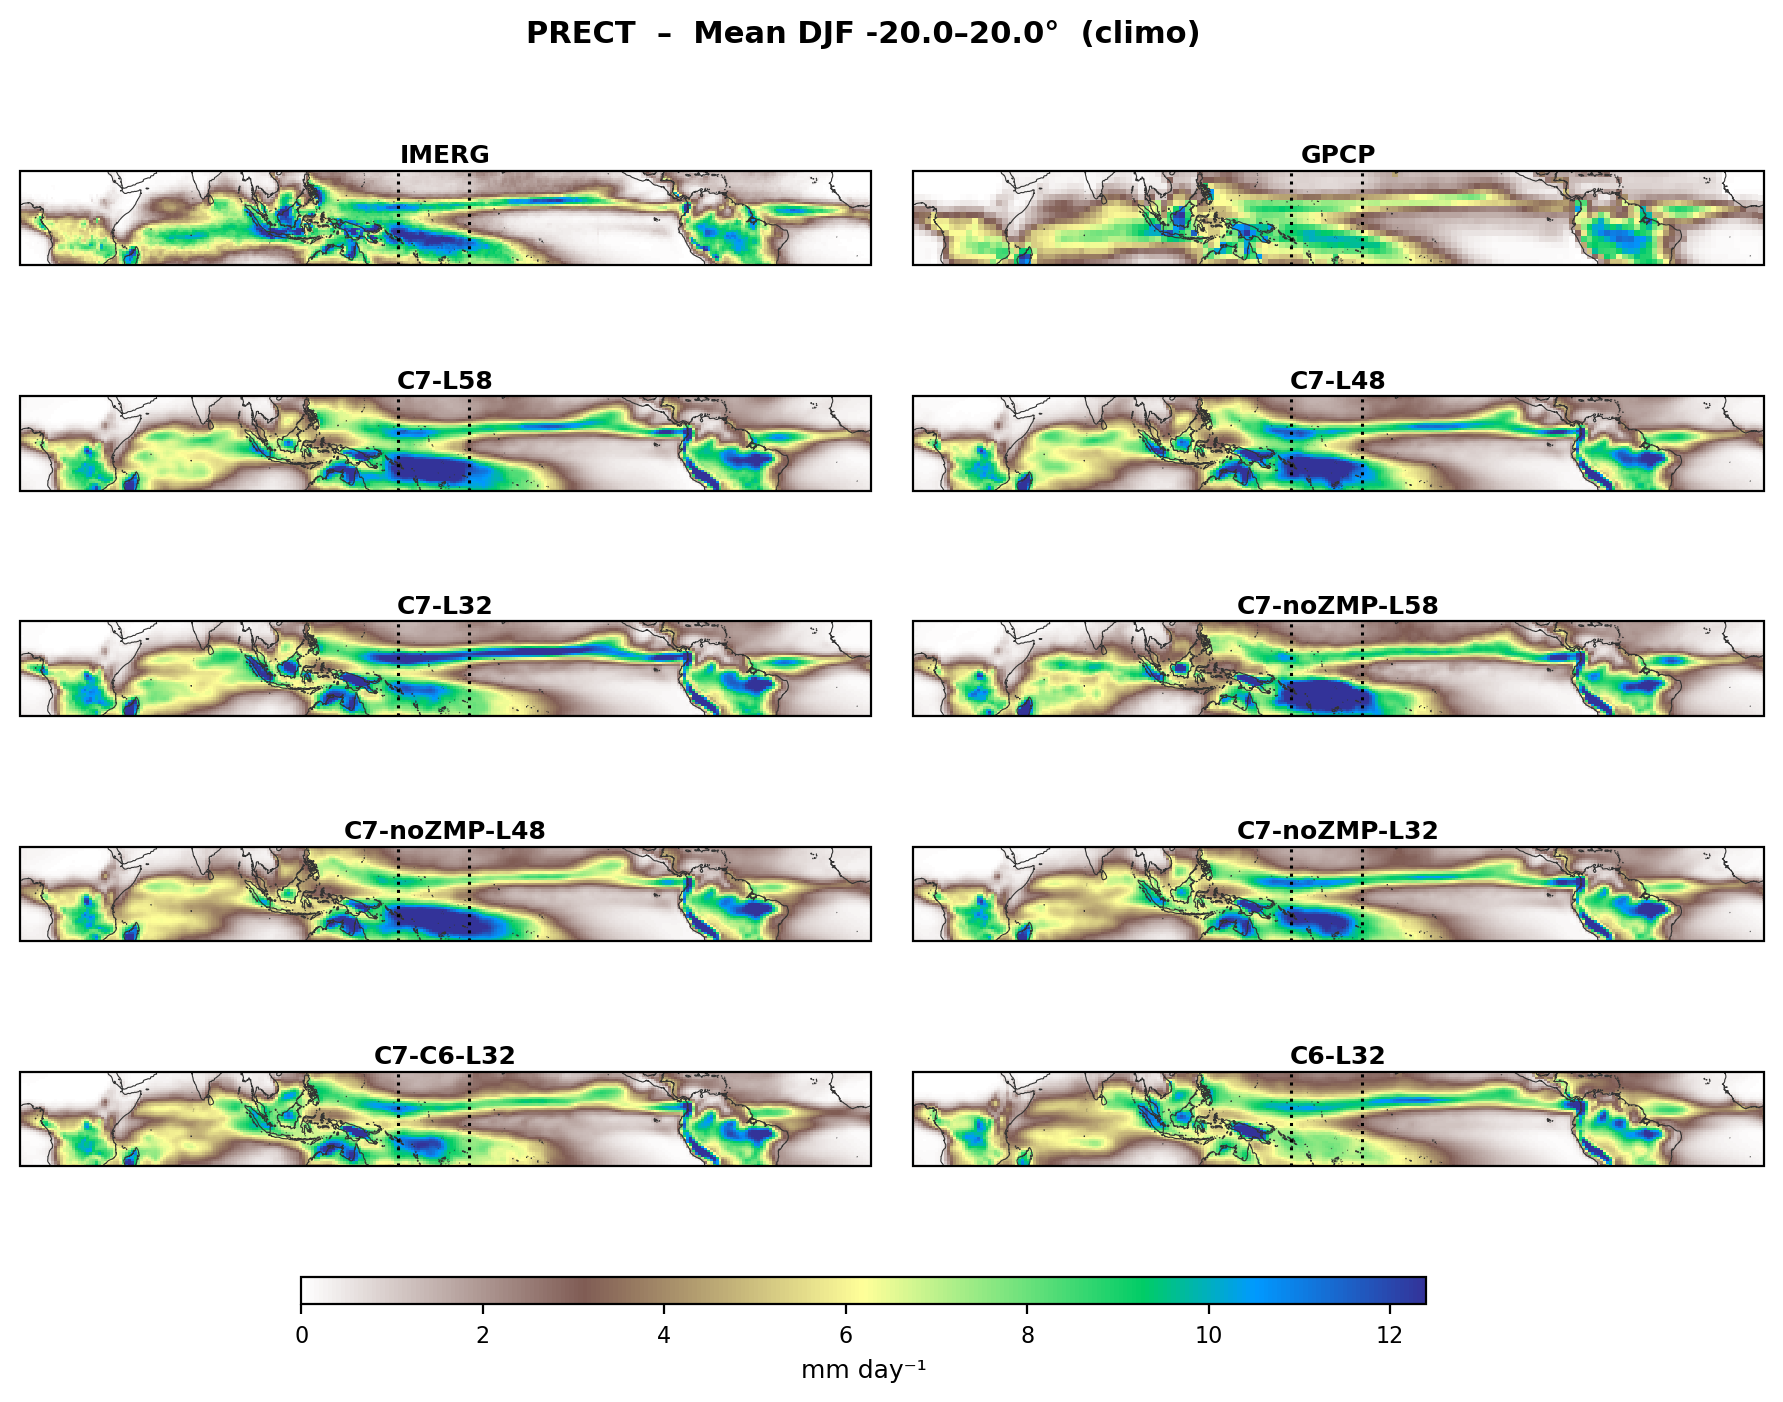

In [90]:
for vname in VARS_TO_PLOT:
    print(f'\n── {vname} ─────────────────────────────────────────────────────')
    plot_mean(vname, show=True)

---
## Bias vs first case

Uses the first entry of `dcases` as the reference; each other case is plotted as `case − ref`. Cases on a different grid are interpolated onto the reference grid before differencing.

In [91]:
def _align_to(da, ref):
    """Interpolate da onto ref's lat/lon grid if they differ."""
    if da.sizes.get('lat') == ref.sizes.get('lat') and \
       da.sizes.get('lon') == ref.sizes.get('lon') and \
       np.allclose(da.lat.values, ref.lat.values) and \
       np.allclose(da.lon.values, ref.lon.values):
        return da
    return da.interp(lat=ref.lat, lon=ref.lon)


def plot_bias(vname, show=True):
    """One figure per variable: bias vs the first panel (obs if present, else first case)."""
    cfg = VAR_CONFIG[vname]

    # Same panel order as plot_mean: obs first, then model cases.
    all_entries = []
    for obs_label, da in obs_means.get(vname, {}).items():
        all_entries.append((obs_label, da))
    for label in CASE_LABELS:
        all_entries.append((label, all_means[vname].get(label)))

    # Reference is the first entry that has data.
    ref_label, ref_da = None, None
    for label, da in all_entries:
        if da is not None:
            ref_label, ref_da = label, da
            break
    if ref_da is None:
        print(f'  No reference data for {vname} — skipping bias plot.')
        return

    # Every other entry becomes a bias panel.
    datasets = []
    for label, da in all_entries:
        if label == ref_label:
            continue
        if da is None:
            datasets.append((label, None))
        else:
            datasets.append((label, _align_to(da, ref_da) - ref_da))

    n_ds = len(datasets)
    if n_ds == 0:
        print(f'  Only one dataset for {vname} — nothing to compare.')
        return
    n_cols = 2
    n_rows = int(np.ceil(n_ds / n_cols))

    arrs = [b for _, b in datasets if b is not None]
    if not arrs:
        print(f'  No comparison data for {vname} — skipping.')
        return
    vmin, vmax, cmap = _compute_clim(arrs, 'RdBu_r')

    if LAT_BOUNDS is None:
        panel_h = 2.2 * 0.75
    else:
        lat_span = max(LAT_BOUNDS) - min(LAT_BOUNDS)
        panel_h  = max(4.4 * lat_span / 180.0, 1.4) * 0.75
    panel_w = 4.5

    proj = ccrs.PlateCarree(central_longitude=180)

    fig_w = panel_w * n_cols * 1.25
    fig_h = (panel_h * n_rows + 0.9) * 1.1
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(fig_w, fig_h),
        subplot_kw={'projection': proj},
    )
    axes_flat = np.array(axes).ravel()
    for ai in range(n_ds, n_rows * n_cols):
        axes_flat[ai].set_visible(False)

    lat0_e = min(LAT_BOUNDS) if LAT_BOUNDS else  -90.
    lat1_e = max(LAT_BOUNDS) if LAT_BOUNDS else   90.
    lon0_e = (min(LON_BOUNDS) if LON_BOUNDS else   0.) - 180.
    lon1_e = (max(LON_BOUNDS) if LON_BOUNDS else 360.) - 180.

    last_im = None
    for ai, (label, da) in enumerate(datasets):
        ax = axes_flat[ai]

        if da is None:
            ax.set_extent([lon0_e, lon1_e, lat0_e, lat1_e], crs=proj)
            ax.coastlines(linewidth=0.4, color='#aaaaaa')
            ax.set_facecolor('#f0f0f0')
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=9, color='#888888')
            ax.set_title(f'{label} − {ref_label}', fontsize=9, fontweight='bold', pad=3)
            _draw_zonal_delims(ax)
            continue

        lat = da.lat.values
        lon = da.lon.values

        lon_span = float(lon.max() - lon.min())
        if lon_span > 350:
            try:
                data_plot, lon_plot = add_cyclic_point(da.values, coord=lon)
            except Exception:
                data_plot, lon_plot = da.values, lon
        else:
            data_plot, lon_plot = da.values, lon

        im = ax.pcolormesh(
            lon_plot, lat, data_plot,
            vmin=vmin, vmax=vmax, cmap=cmap,
            transform=ccrs.PlateCarree(),
            rasterized=True,
        )

        if LAT_BOUNDS is None and LON_BOUNDS is None:
            ax.set_global()
        else:
            ax.set_extent([lon0_e, lon1_e, lat0_e, lat1_e], crs=proj)

        ax.coastlines(linewidth=0.4, color='#333333')
        mean_bias = float(np.nanmean(da.values))
        rmse      = float(np.sqrt(np.nanmean(da.values**2)))
        ax.set_title(f'{label} − {ref_label}   (mean {mean_bias:+.2f}, RMSE {rmse:.2f})',
                     fontsize=9, fontweight='bold', pad=3)
        _draw_zonal_delims(ax)
        last_im = im

    fig.subplots_adjust(top=0.90, bottom=0.08, hspace=0.08, wspace=0.05)
    cbar_ax = fig.add_axes([0.25, 0.02, 0.50, 0.020])
    cbar = fig.colorbar(last_im, cax=cbar_ax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label(cfg['units'], fontsize=9)

    lev_str = f' @ {cfg["lev"]} hPa' if cfg['lev'] else ''
    lat_str = f' {min(LAT_BOUNDS)}–{max(LAT_BOUNDS)}°' if LAT_BOUNDS else ''
    fig.suptitle(
        f'{vname}{lev_str}  –  Bias vs {ref_label}, {SEASON}{lat_str}  (climo)',
        fontsize=11, fontweight='bold', y=0.97,
    )

    lev_tag = f'_{cfg["lev"]}hPa' if cfg['lev'] else ''
    lat_tag = f'_{min(LAT_BOUNDS)}to{max(LAT_BOUNDS)}' if LAT_BOUNDS else ''
    fpath = DIR_FIG / f'cam7_climo_bias_{vname}{lev_tag}_{SEASON}{lat_tag}.png'
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f'  Saved: {fpath}')
    if show:
        ipy_display(Image(str(fpath)))

print('plot_bias() defined.')

plot_bias() defined.



── PRECT bias vs C7-L58 ─────────────────────
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_climo_bias_PRECT_DJF_-20.0to20.0.png


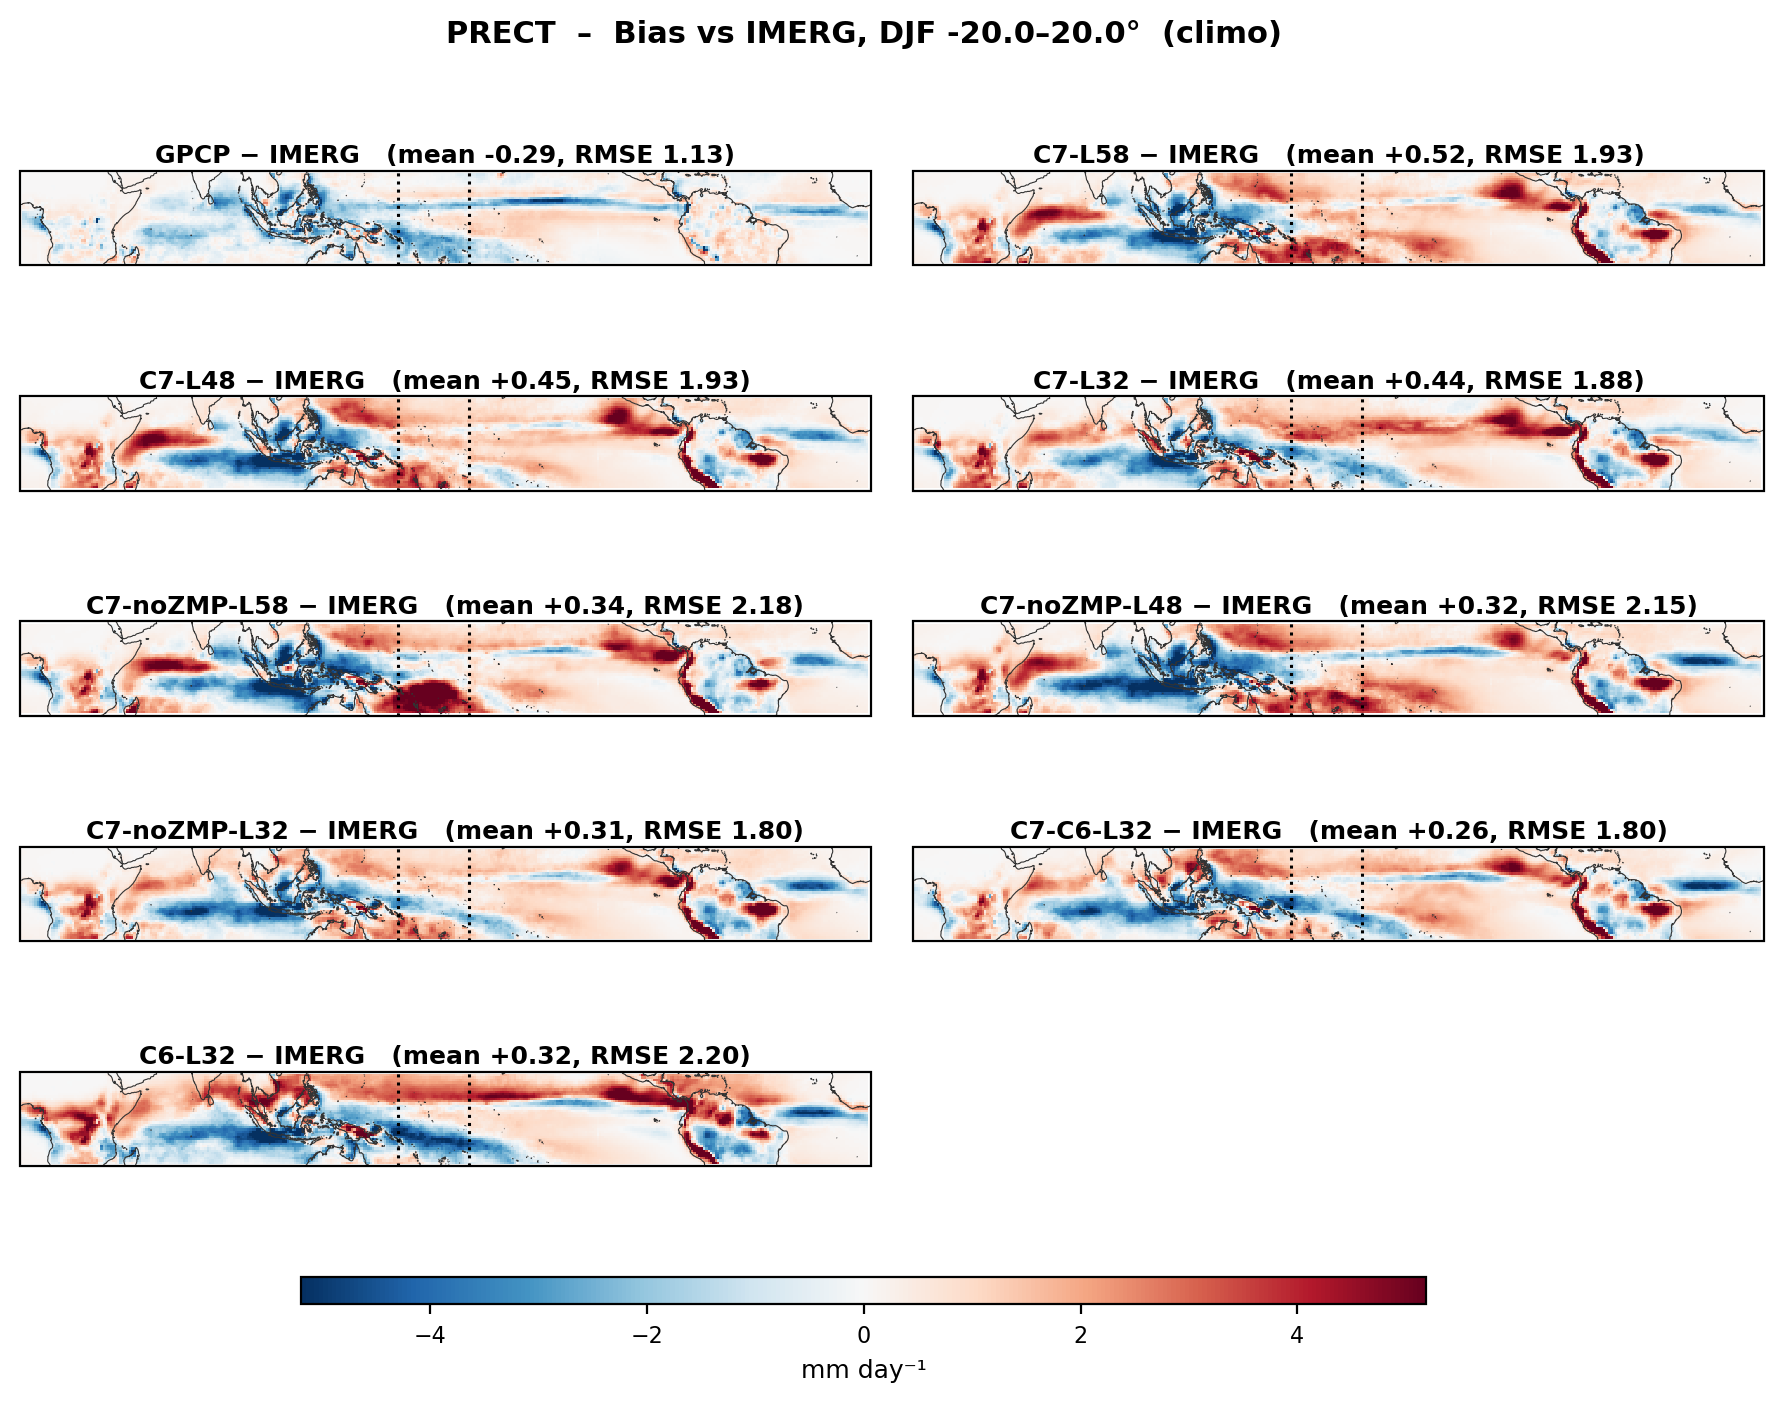

In [92]:
for vname in VARS_TO_PLOT:
    print(f'\n── {vname} bias vs {CASE_LABELS[0]} ─────────────────────')
    plot_bias(vname, show=True)

---
## Zonal cross section

Field averaged in longitude between `ZONAL_LON_BOUNDS`, plotted vs latitude for obs + every case.


── PRECT zonal section (160.0, 190.0) ─────────────────────
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_climo_zonal_PRECT_DJF_160to190.png


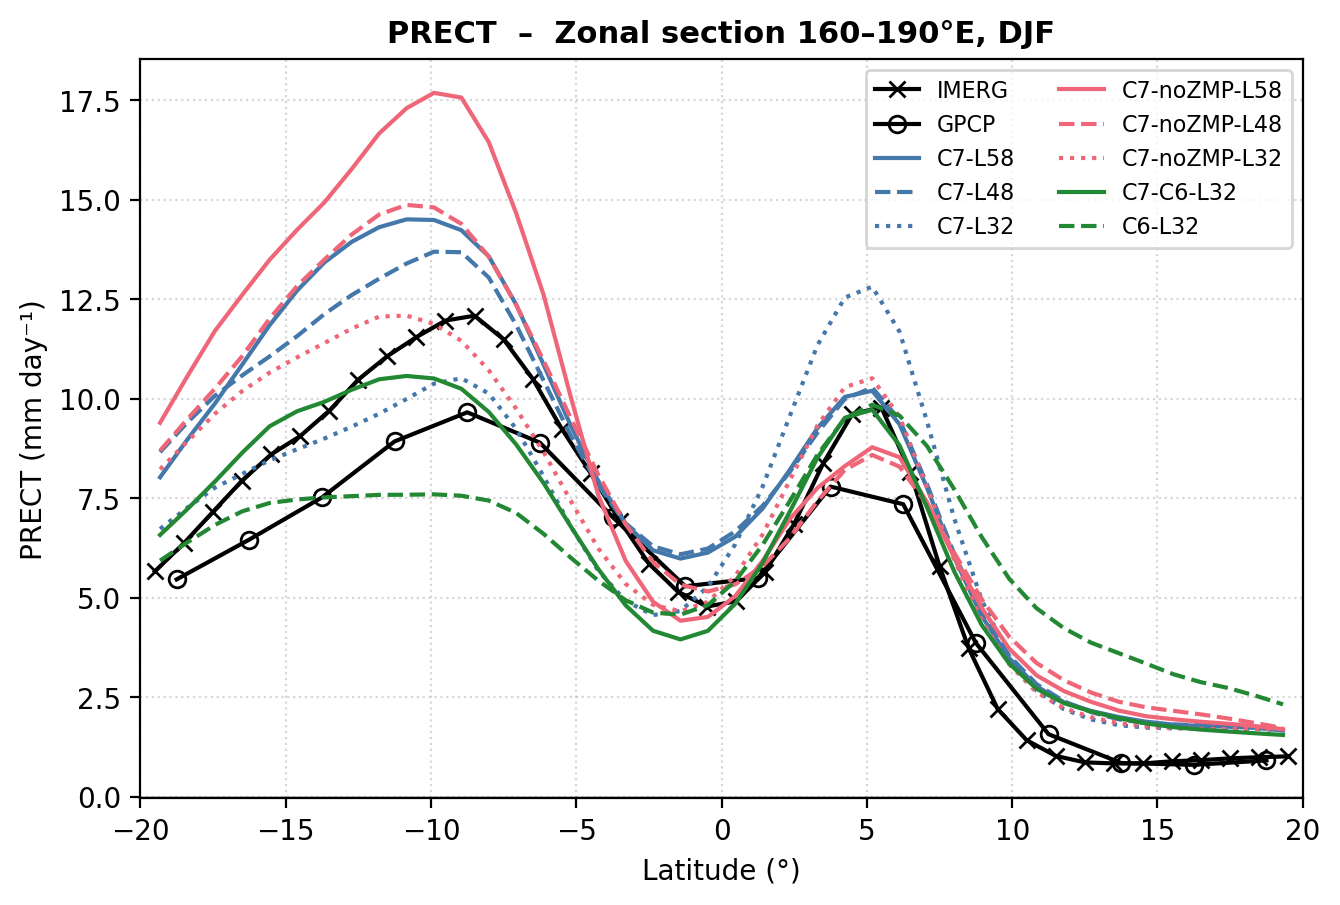

In [93]:
def _lon_mean(da, lon_bounds):
    """Longitude-mean of da between lon_bounds (inclusive). Handles wrap-around."""
    lo, hi = lon_bounds
    lon_vals = da.lon.values
    # If file uses -180..180 and bounds are 0..360, shift bounds.
    if lo >= 0 and lon_vals.min() < 0:
        lo -= 360 if lo > 180 else 0
        hi -= 360 if hi > 180 else 0
    if hi >= lo:
        sub = da.where((da.lon >= lo) & (da.lon <= hi), drop=True)
    else:
        # wraps the dateline
        sub = da.where((da.lon >= lo) | (da.lon <= hi), drop=True)
    return sub.mean(dim='lon')


# Marker cycle used to distinguish multiple obs sources.
OBS_MARKERS = ['x', 'o', 's', '^', 'D', 'v', '*']


def plot_zonal_section(vname, show=True):
    """Line plot of the field averaged in longitude across ZONAL_LON_BOUNDS.
    All line styling comes from the shared _line_style() helper."""
    if ZONAL_LON_BOUNDS is None:
        print('  ZONAL_LON_BOUNDS not set — skipping zonal section.')
        return
    cfg = VAR_CONFIG[vname]
    lo, hi = ZONAL_LON_BOUNDS

    obs_dict = obs_means.get(vname, {})

    fig, ax = plt.subplots(figsize=(7.5, 4.8))

    n_plotted = 0

    for i, (obs_label, da) in enumerate(obs_dict.items()):
        if da is None:
            continue
        line = _lon_mean(da, ZONAL_LON_BOUNDS)
        marker = OBS_MARKERS[i % len(OBS_MARKERS)]
        ax.plot(line.lat.values, line.values, label=obs_label,
                **_line_style(obs_label, is_obs=True, obs_marker=marker))
        n_plotted += 1

    for label in CASE_LABELS:
        da = all_means[vname].get(label)
        if da is None:
            continue
        line = _lon_mean(da, ZONAL_LON_BOUNDS)
        ax.plot(line.lat.values, line.values, label=label, **_line_style(label))
        n_plotted += 1

    if n_plotted == 0:
        plt.close(fig)
        print(f'  No data for {vname} zonal section — skipping.')
        return

    ax.set_xlabel('Latitude (°)')
    ax.set_ylabel(f'{vname} ({cfg["units"]})')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.axhline(0., color='k', linewidth=0.5)
    if LAT_BOUNDS is not None:
        ax.set_xlim(min(LAT_BOUNDS), max(LAT_BOUNDS))
    ax.legend(fontsize=8, loc='best', ncol=2)

    lev_str = f' @ {cfg["lev"]} hPa' if cfg['lev'] else ''
    ax.set_title(
        f'{vname}{lev_str}  –  Zonal section {lo:g}–{hi:g}°E, {SEASON}',
        fontsize=11, fontweight='bold',
    )

    lev_tag = f'_{cfg["lev"]}hPa' if cfg['lev'] else ''
    fpath = DIR_FIG / f'cam7_climo_zonal_{vname}{lev_tag}_{SEASON}_{int(lo)}to{int(hi)}.png'
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f'  Saved: {fpath}')
    if show:
        ipy_display(Image(str(fpath)))


for vname in VARS_TO_PLOT:
    print(f'\n── {vname} zonal section {ZONAL_LON_BOUNDS} ─────────────────────')
    plot_zonal_section(vname, show=True)

---
## Vertical profiles

Area-averaged profile (cos-lat weighted) over `PROFILE_LAT_BOUNDS × PROFILE_LON_BOUNDS`,
per case, plotted against pressure. ERA5 (from `/glade/derecho/scratch/rneale/ERA5/mmean/1deg`)
is overlaid as a black reference line for variables that have an ERA5 counterpart.


── T vertical profile ─────────────────────
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_climo_profile_T_native_precgt1_DJF_lat-20to0.png


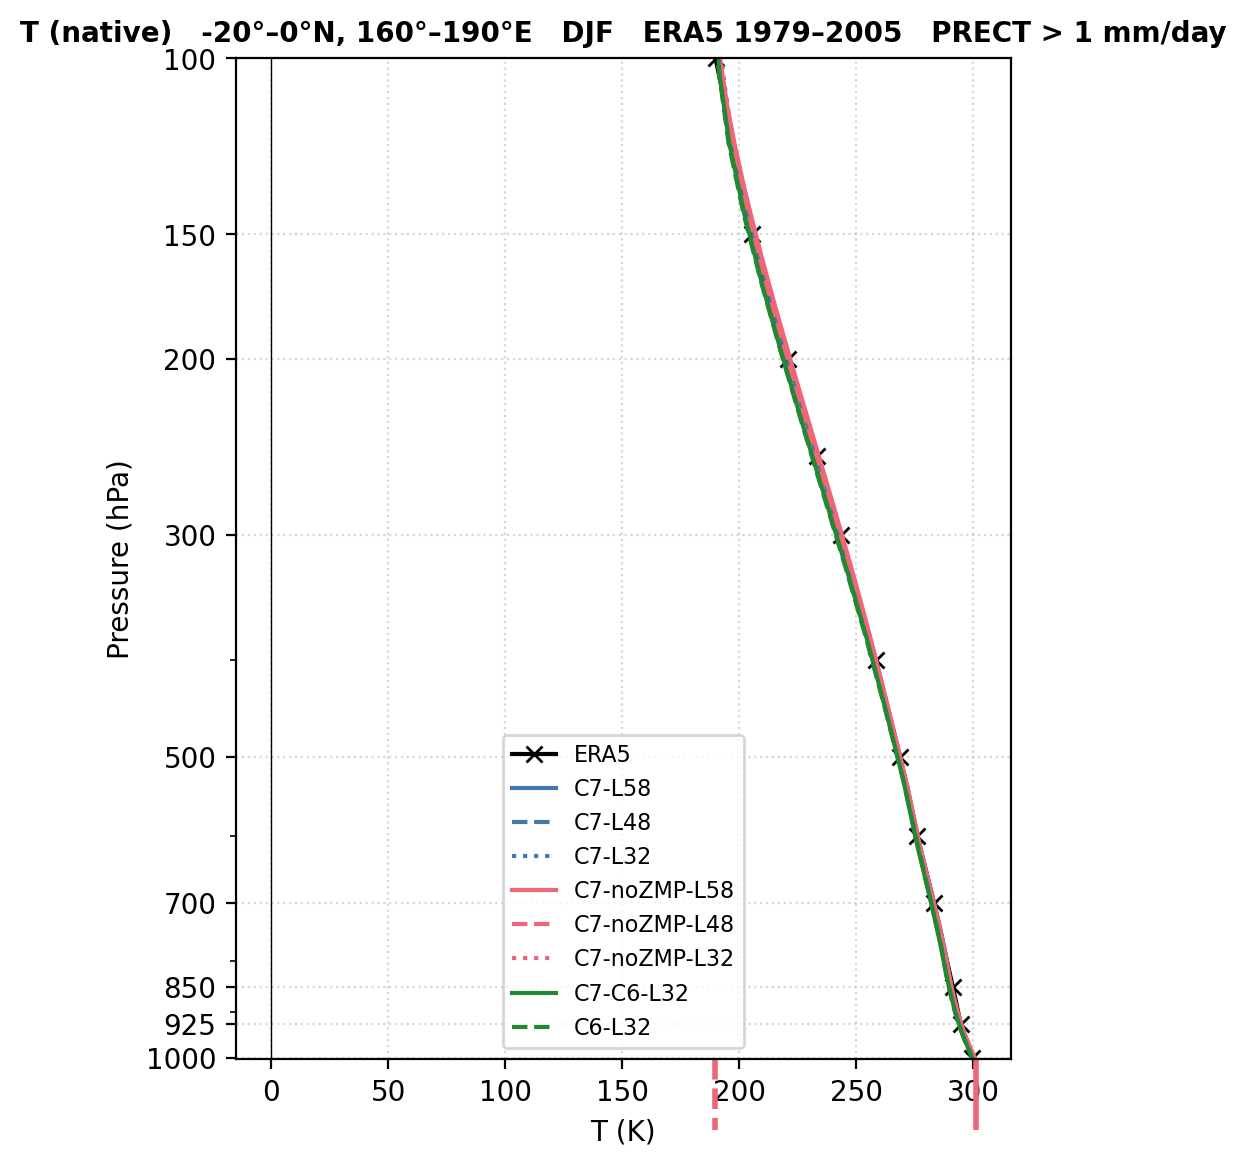


── Q vertical profile ─────────────────────
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_climo_profile_Q_native_precgt1_DJF_lat-20to0.png


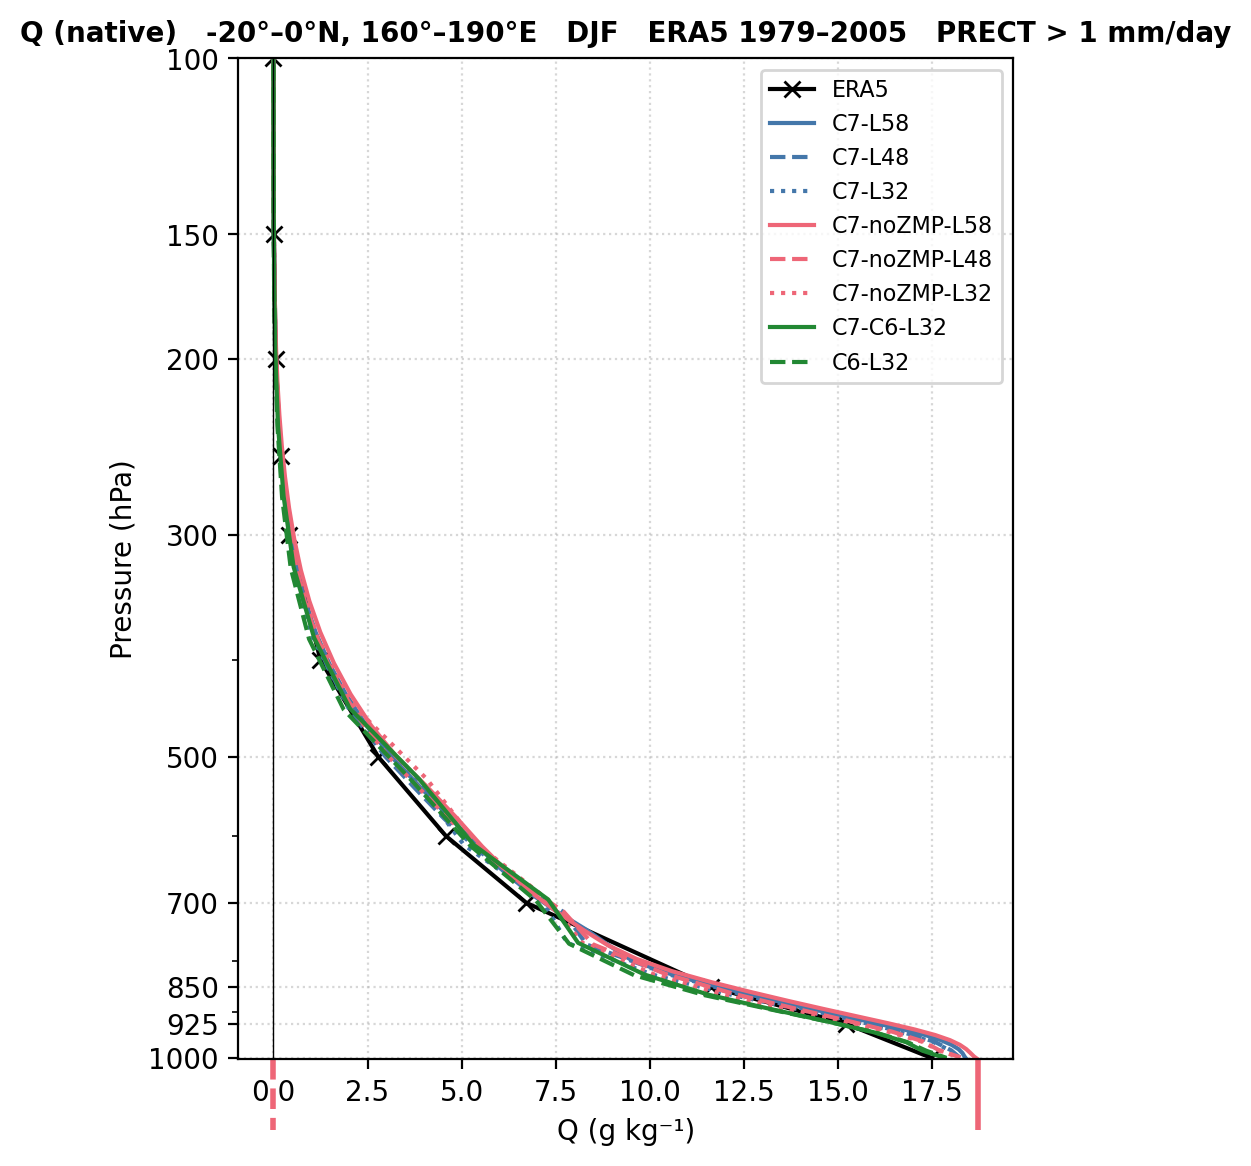


── U vertical profile ─────────────────────
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_climo_profile_U_native_precgt1_DJF_lat-20to0.png


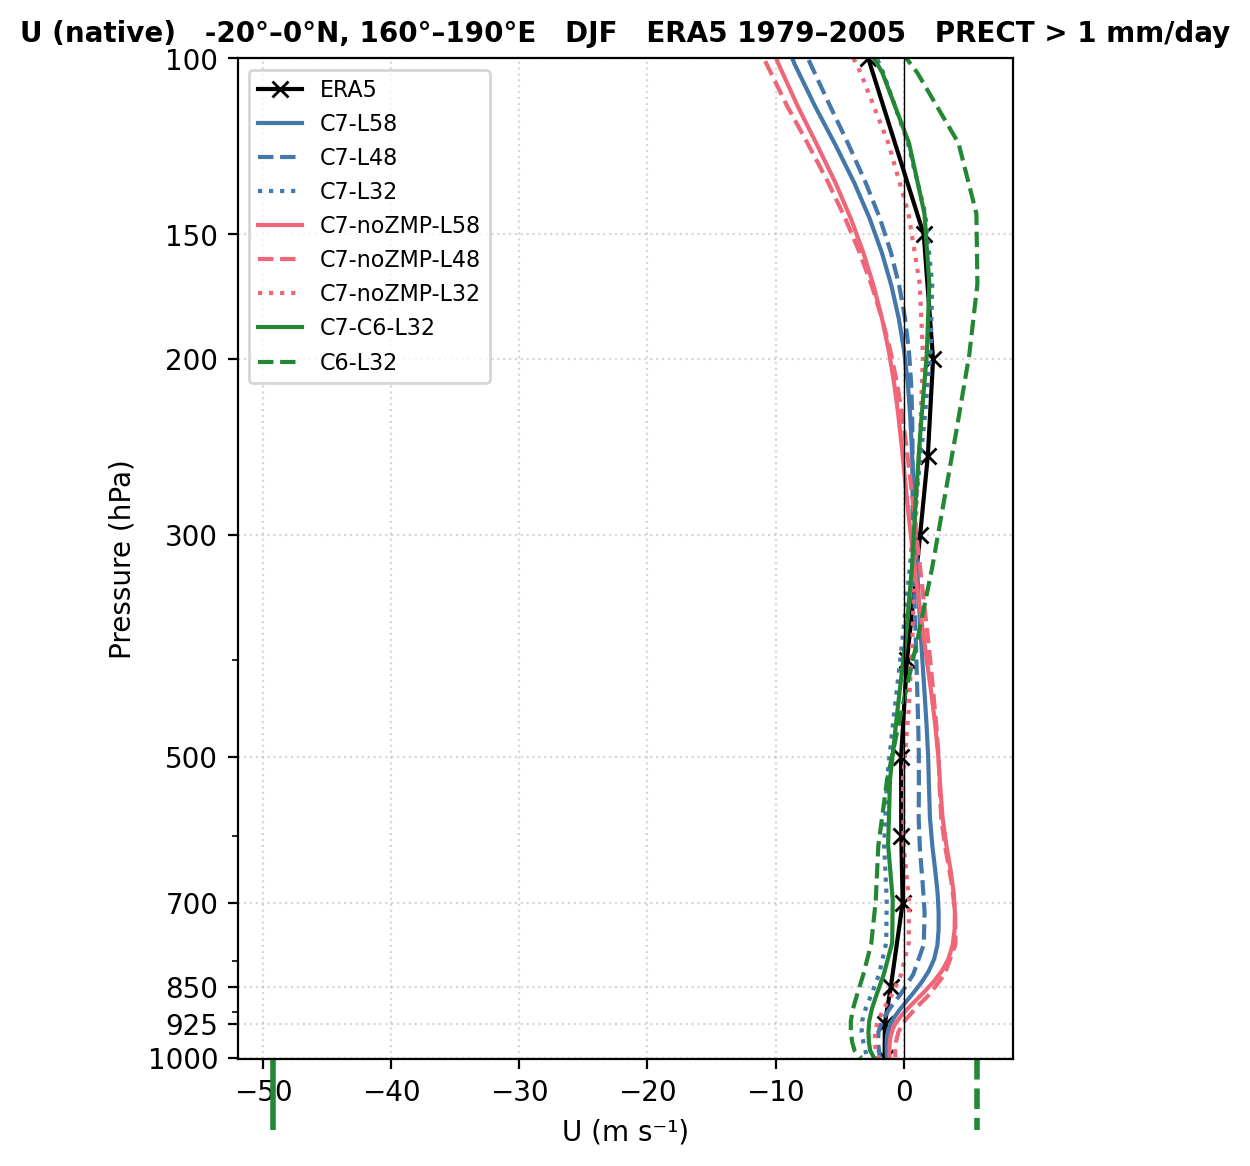


── OMEGA vertical profile ─────────────────────
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_climo_profile_OMEGA_native_precgt1_DJF_lat-20to0.png


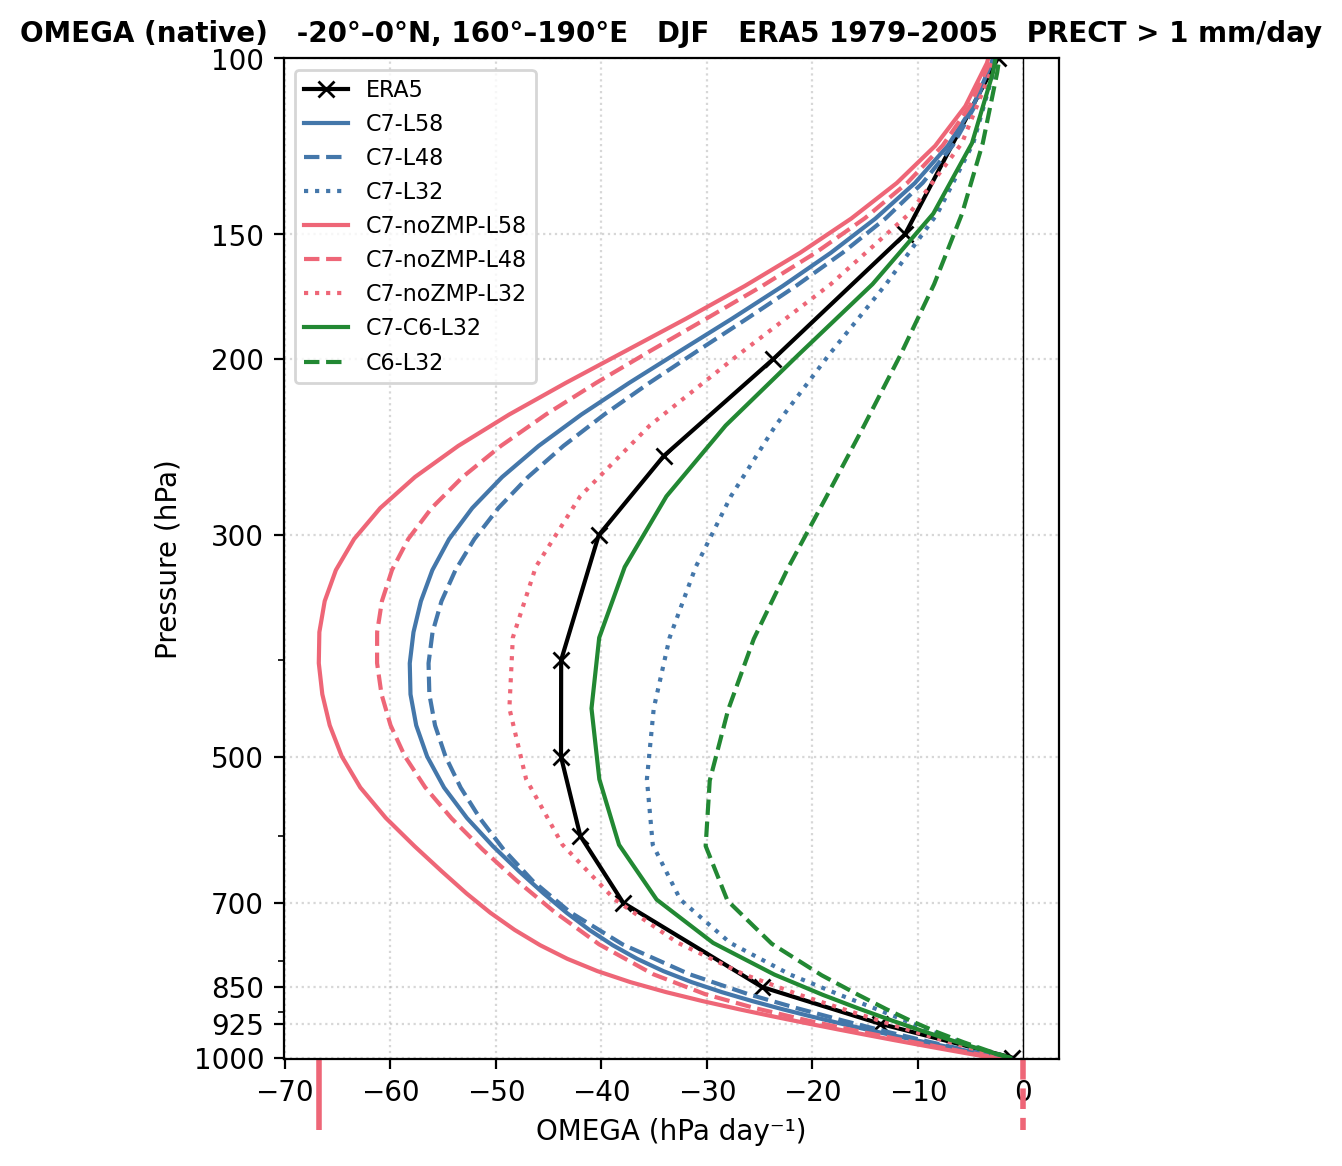


── ZMDT vertical profile ─────────────────────
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_climo_profile_ZMDT_native_precgt1_DJF_lat-20to0.png


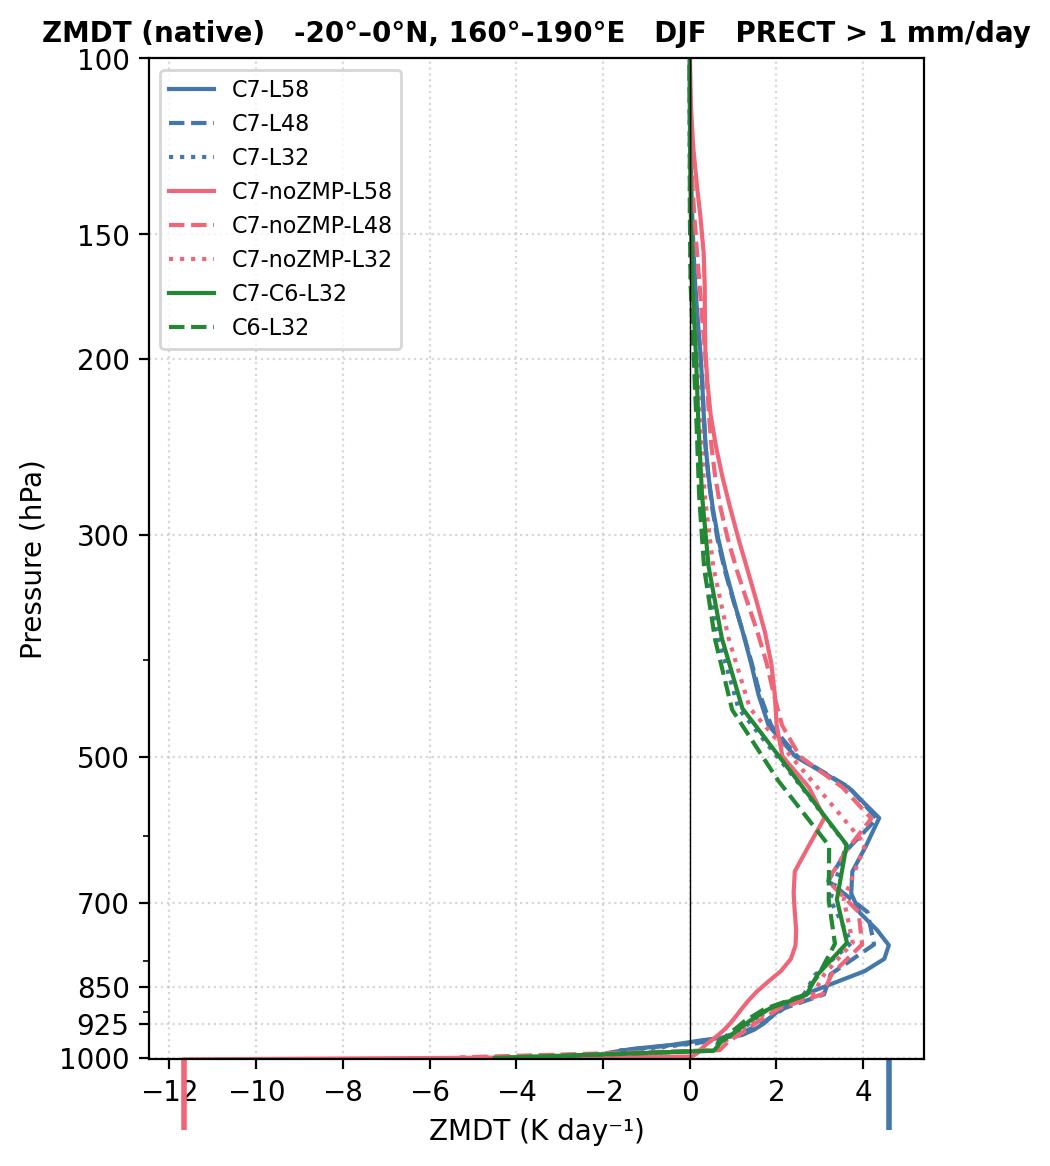


── ZMDQ vertical profile ─────────────────────
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_climo_profile_ZMDQ_native_precgt1_DJF_lat-20to0.png


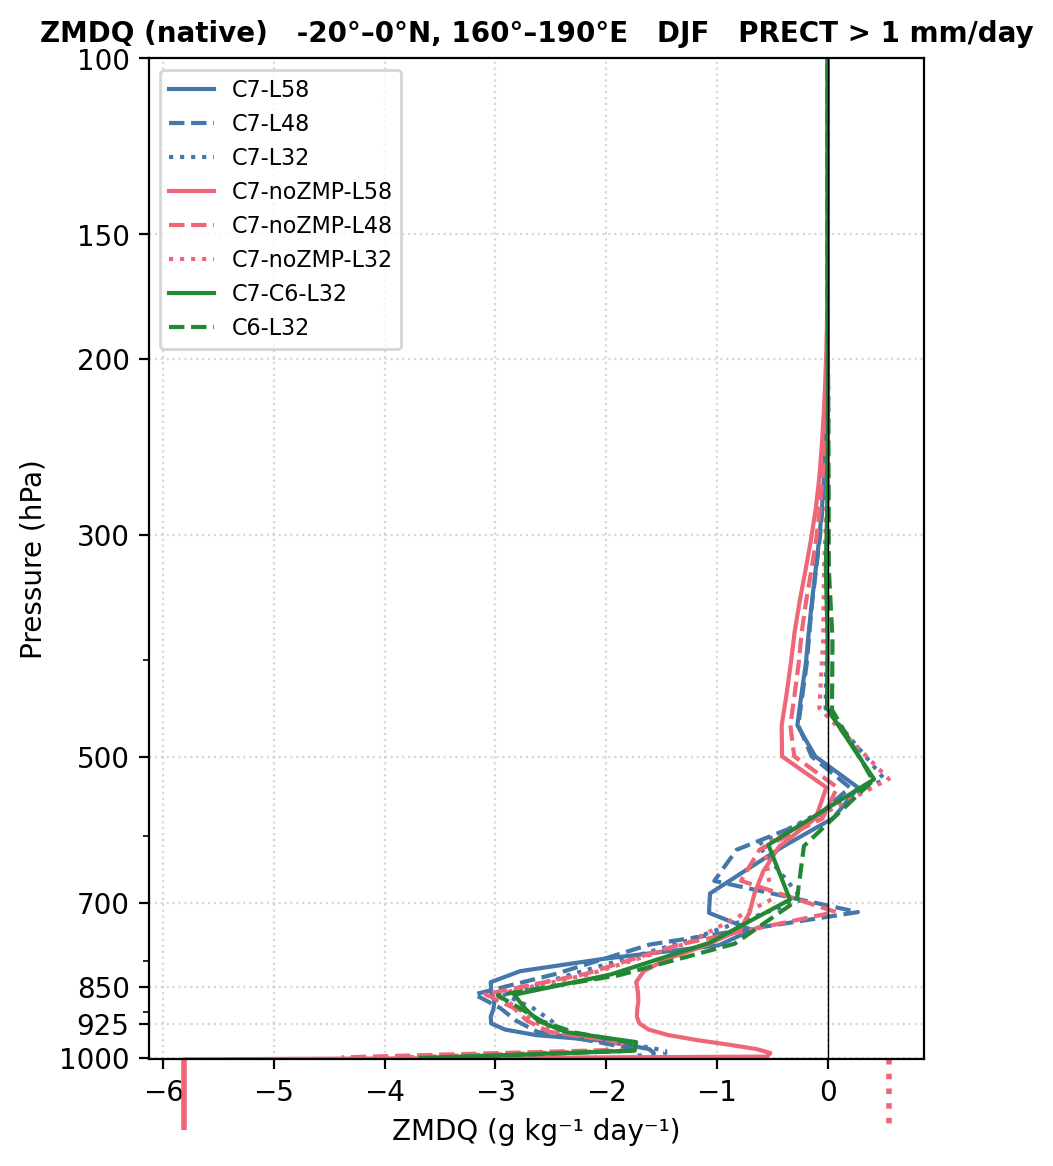


── STEND_CLUBB vertical profile ─────────────────────
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_climo_profile_STEND_CLUBB_native_precgt1_DJF_lat-20to0.png


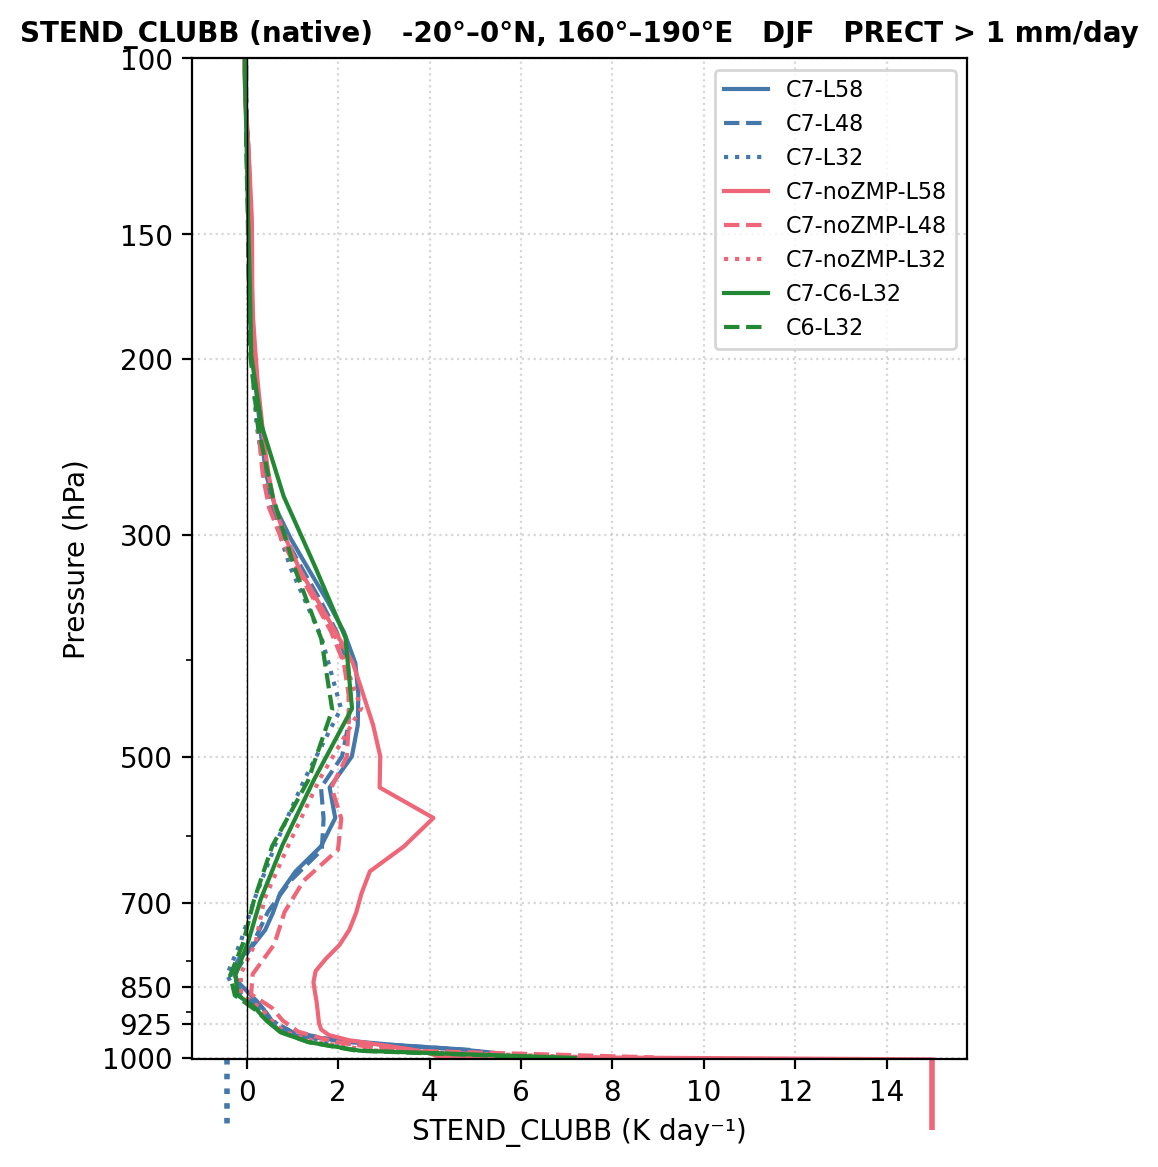


── RVMTEND_CLUBB vertical profile ─────────────────────
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_climo_profile_RVMTEND_CLUBB_native_precgt1_DJF_lat-20to0.png


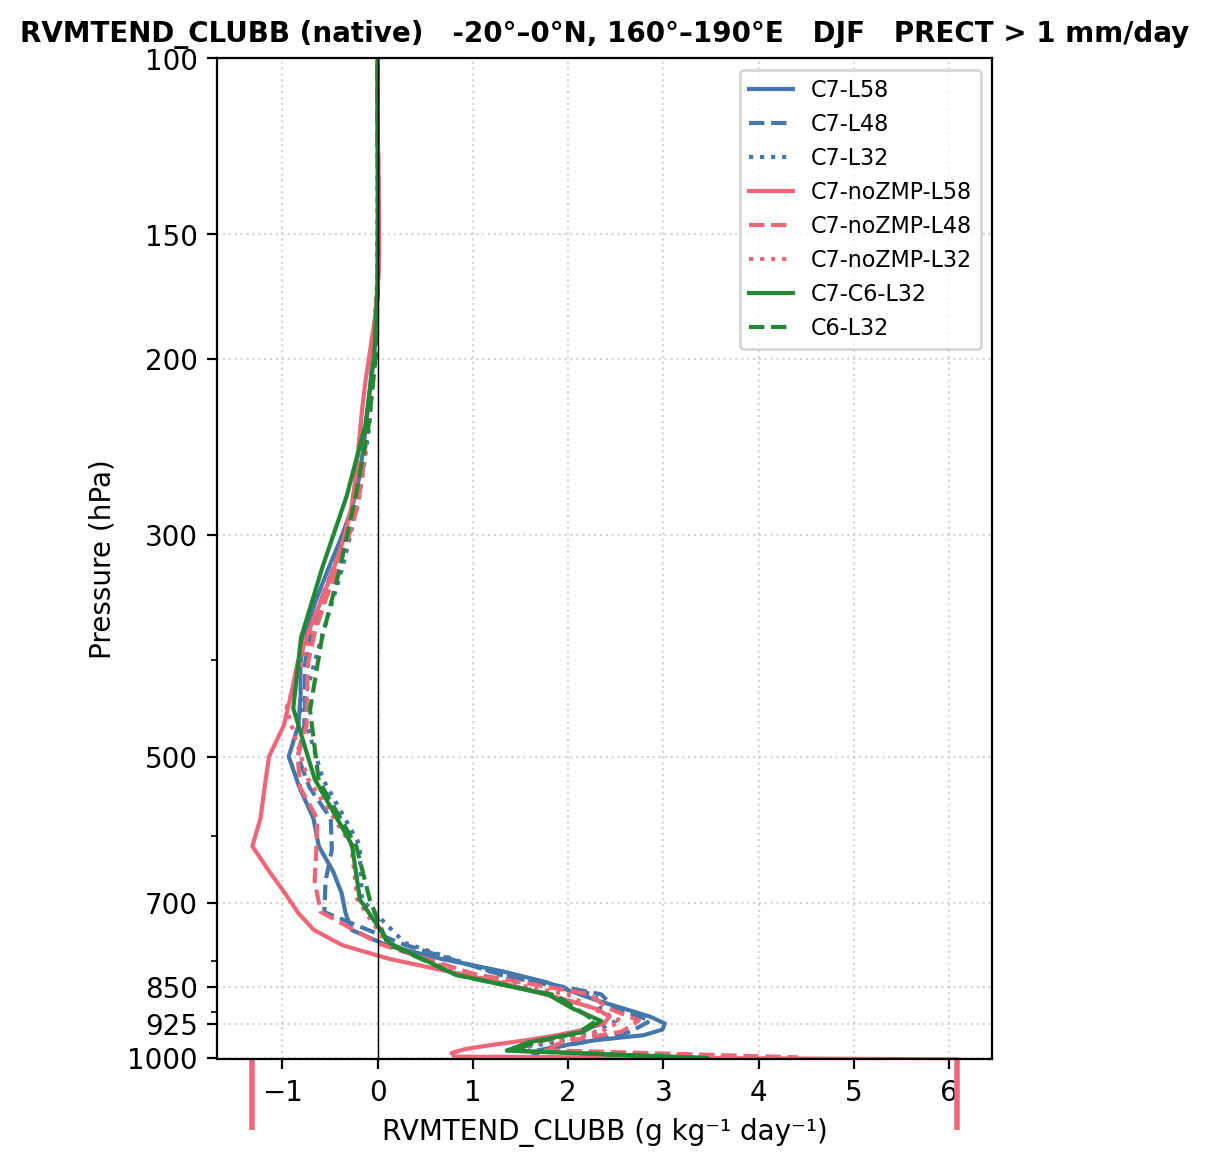

In [94]:
import matplotlib.ticker as mticker
from matplotlib.transforms import blended_transform_factory as _btf

_SEASON_MONTHS = {
    'ANN': list(range(1, 13)),
    'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11],
}

def _season_months(tag):
    if tag in _SEASON_MONTHS:
        return _SEASON_MONTHS[tag]
    try:
        return [int(tag)]
    except Exception:
        raise ValueError(f'Unrecognized season tag {tag!r}')


def _slice_region(da, lat_bounds, lon_bounds):
    """Region-slice a lat/lon DataArray; handles -180..180 vs 0..360 and wrap."""
    lat0, lat1 = min(lat_bounds), max(lat_bounds)
    lon0, lon1 = lon_bounds
    da = da.where((da.lat >= lat0) & (da.lat <= lat1), drop=True)
    if lon0 >= 0 and float(da.lon.min()) < 0:
        lo = lon0 - 360 if lon0 > 180 else lon0
        hi = lon1 - 360 if lon1 > 180 else lon1
    else:
        lo, hi = lon0, lon1
    if hi >= lo:
        da = da.where((da.lon >= lo) & (da.lon <= hi), drop=True)
    else:
        da = da.where((da.lon >= lo) | (da.lon <= hi), drop=True)
    return da


def _cos_lat_mean(da):
    """cos(lat)-weighted mean over remaining lat, lon dims (skips NaN)."""
    w = np.cos(np.deg2rad(da.lat))
    return da.weighted(w).mean(dim=('lat', 'lon'))


def _cam_prect_mask(ds, threshold_mmday):
    """2-D (lat,lon) True/False mask: local climo PRECT > threshold, region-sliced.
    Returns None if PRECT missing from ds."""
    if 'PRECT' not in ds.variables:
        return None
    prect = ds['PRECT']
    if 'time' in prect.dims: prect = prect.isel(time=0)
    prect = prect * 86400. * 1000.   # kg/m²/s → mm/day
    prect_r = _slice_region(prect, PROFILE_LAT_BOUNDS, PROFILE_LON_BOUNDS).load()
    return prect_r > threshold_mmday


def _era5_prect_mask(season, year_range, threshold_mmday):
    """2-D (lat,lon) mask from ERA5 monthly tp climo. None if file missing."""
    fpath = ERA5_ROOT / 'prect' / 'prect_era5_monthly_1x1.nc'
    if not fpath.exists():
        print(f'  ERA5 prect file missing — cannot build PRECT mask.')
        return None
    ds = xr.open_dataset(fpath)
    tname = 'valid_time' if 'valid_time' in ds.dims else 'time'
    da = ds['tp']
    years  = da[tname].dt.year.values
    months = da[tname].dt.month.values
    y0, y1 = year_range
    wanted = set(_season_months(season))
    mask_t = (years >= y0) & (years <= y1) & np.isin(months, list(wanted))
    if mask_t.sum() == 0:
        ds.close(); return None
    prect = da.isel({tname: mask_t}).mean(dim=tname) * 1000.   # m/day → mm/day
    if float(prect.lon.min()) < 0:
        prect = prect.assign_coords(lon=(prect.lon.values % 360)).sortby('lon')
    prect_r = _slice_region(prect, PROFILE_LAT_BOUNDS, PROFILE_LON_BOUNDS).load()
    ds.close()
    return prect_r > threshold_mmday


def _cam_profile(case, vname, season, scale, target_plev, use_native=False,
                 prect_mask=None):
    """CAM 3-D field → 1-D vertical profile over the profile region.
    use_native=False → per-column interp onto target_plev, then area-average.
    use_native=True  → area-average variable and PMID at each native hybrid level.
    prect_mask (2-D bool DataArray or None): if given, columns where mask=False
    are set to NaN before the area mean."""
    fpath = climo_file(case, season)
    if not fpath.exists():
        return None
    ds = xr.open_dataset(fpath, decode_times=False)
    if vname not in ds.variables:
        ds.close(); return None
    da = ds[vname]
    if 'time' in da.dims:
        da = da.isel(time=0)
    if 'lev' not in da.dims:
        print(f'  {case}: {vname} is not 3D (no lev dim) — skipping')
        ds.close(); return None

    # Mid-level pressure field.  Prefer PMID (3-D); fall back to hyam/hybm/PS.
    if 'PMID' in ds.variables:
        pmid = ds['PMID']
        if 'time' in pmid.dims: pmid = pmid.isel(time=0)
    elif {'hyam', 'hybm', 'PS'}.issubset(ds.variables):
        ps = ds['PS']
        if 'time' in ps.dims: ps = ps.isel(time=0)
        P0 = float(ds['P0']) if 'P0' in ds.variables else 100000.
        pmid = ds['hyam'] * P0 + ds['hybm'] * ps
    else:
        print(f'  {case}: no PMID/hybrid info — cannot build pressure axis, skipping.')
        ds.close(); return None
    pmid_hPa = pmid / 100.

    # Region slice first (much smaller), then load into memory.
    da_r   = _slice_region(da,        PROFILE_LAT_BOUNDS, PROFILE_LON_BOUNDS).load() * scale
    pmid_r = _slice_region(pmid_hPa,  PROFILE_LAT_BOUNDS, PROFILE_LON_BOUNDS).load()
    ds.close()

    if use_native:
        # Area-average variable and pressure separately → 1-D on native lev.
        if prect_mask is not None:
            da_r   = da_r.where(prect_mask)
            pmid_r = pmid_r.where(prect_mask)
        prof = _cos_lat_mean(da_r)
        pres = _cos_lat_mean(pmid_r).values
        return xr.DataArray(prof.values, coords={'plev': ('plev', pres)},
                            dims=('plev',), name=vname)

    # Per-column linear interp onto common target pressure grid.
    target = np.asarray(target_plev, dtype=float)
    # left=NaN handles above-atmosphere; right=NaN handles below-surface (over
    # topography). NaNs are then skipped by the cos-lat weighted mean.
    def _interp_col(v, p):
        return np.interp(target, p, v, left=np.nan, right=np.nan)

    on_plev = xr.apply_ufunc(
        _interp_col, da_r, pmid_r,
        input_core_dims=[['lev'], ['lev']],
        output_core_dims=[['plev']],
        vectorize=True,
        output_dtypes=[float],
    ).assign_coords(plev=target)

    if prect_mask is not None:
        on_plev = on_plev.where(prect_mask)

    prof = _cos_lat_mean(on_plev)
    return xr.DataArray(prof.values, coords={'plev': ('plev', target)},
                        dims=('plev',), name=vname)


def _era5_profile(vname, season, year_range, scale, prect_mask=None):
    """ERA5 monthly-mean file → seasonal, year-range, area-mean profile
    on the file's native pressure_level grid."""
    cfg = PROFILE_VARS[vname]
    if cfg.get('era5_dir') is None:
        return None
    d = cfg['era5_dir']
    fpath = ERA5_ROOT / d / f'{d}_era5_monthly_1x1.nc'
    if not fpath.exists():
        print(f'  ERA5 file missing: {fpath}')
        return None
    ds = xr.open_dataset(fpath)
    if cfg['era5_var'] not in ds.variables:
        ds.close(); return None
    tname = 'valid_time' if 'valid_time' in ds.dims else 'time'
    da = ds[cfg['era5_var']]
    years  = da[tname].dt.year.values
    months = da[tname].dt.month.values
    y0, y1 = year_range
    wanted = set(_season_months(season))
    mask = (years >= y0) & (years <= y1) & np.isin(months, list(wanted))
    if mask.sum() == 0:
        print(f'  ERA5 {vname}: no months in {year_range} matching {season}')
        ds.close(); return None
    da = da.isel({tname: mask}).mean(dim=tname) * scale
    if float(da.lon.min()) < 0:
        da = da.assign_coords(lon=(da.lon.values % 360)).sortby('lon')
    da_r = _slice_region(da, PROFILE_LAT_BOUNDS, PROFILE_LON_BOUNDS).load()
    if prect_mask is not None:
        da_r = da_r.where(prect_mask)
    prof = _cos_lat_mean(da_r)
    pres = prof['pressure_level'].values.astype(float)
    ds.close()
    return xr.DataArray(prof.values, coords={'plev': ('plev', pres)},
                        dims=('plev',), name=vname)


def plot_vertical_profile(vname, show=True):
    if vname not in PROFILE_VARS:
        print(f'  {vname} not in PROFILE_VARS — skipping.'); return
    cfg = PROFILE_VARS[vname]
    season = PROFILE_SEASON or SEASON
    scale  = cfg['scale']

    # Pre-compute ERA5's PRECT mask once (if threshold is set).
    era5_mask = None
    if PROFILE_PRECT_THRESHOLD is not None:
        era5_mask = _era5_prect_mask(season, ERA5_YEAR_RANGE, PROFILE_PRECT_THRESHOLD)

    entries = []                      # (label, DataArray, is_obs)
    era5 = _era5_profile(vname, season, ERA5_YEAR_RANGE, scale, prect_mask=era5_mask)
    if era5 is not None:
        entries.append(('ERA5', era5, True))

    for case, label in zip(CASES, CASE_LABELS):
        # Build a case-specific PRECT mask from the same climo file.
        cam_mask = None
        if PROFILE_PRECT_THRESHOLD is not None:
            f = climo_file(case, season)
            if f.exists():
                with xr.open_dataset(f, decode_times=False) as _ds:
                    cam_mask = _cam_prect_mask(_ds, PROFILE_PRECT_THRESHOLD)
        prof = _cam_profile(case, vname, season, scale, PROFILE_PLEV,
                            use_native=PROFILE_USE_NATIVE_LEVELS,
                            prect_mask=cam_mask)
        if prof is not None:
            entries.append((label, prof, False))

    if not entries:
        print(f'  No data for {vname} profile — skipping.')
        return

    fig, ax = plt.subplots(figsize=(5.0, 6.5))
    for label, prof, is_obs in entries:
        ax.plot(prof.values, prof.plev.values, label=label,
                **_line_style(label, is_obs=is_obs))

    # y-axis: pressure decreasing upward, bottom = max data pressure,
    # top = min data pressure but never below 100 hPa.
    all_p = np.concatenate([prof.plev.values for _, prof, _ in entries])
    p_bottom = float(np.nanmax(all_p))
    p_top    = max(float(np.nanmin(all_p)), 100.)
    ax.set_yscale('log')
    ax.set_ylim(p_bottom, p_top)   # bottom > top → surface at bottom
    ticks = [t for t in (1000, 925, 850, 700, 500, 300, 200, 150, 100)
             if p_top <= t <= p_bottom]
    ax.set_yticks(ticks)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.set_ylabel('Pressure (hPa)')
    ax.set_xlabel(f'{vname} ({cfg["units"]})')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.axvline(0., color='k', linewidth=0.5)
    ax.legend(fontsize=8, loc='best')

    # ── Two vertical ticks on the bottom x-axis: plot-wide min and max ────
    # Find which model case owns the single global minimum and maximum across
    # all cases and all levels, then draw one vertical tick at each x position
    # styled (color + linestyle) to match that case's profile line.
    _global_min, _global_max = np.inf, -np.inf
    _min_lbl, _max_lbl = None, None
    for _lbl, _prf, _obs in entries:
        if _obs:
            continue
        _v = _prf.values[np.isfinite(_prf.values)]
        if len(_v) == 0:
            continue
        if _v.min() < _global_min:
            _global_min, _min_lbl = float(_v.min()), _lbl
        if _v.max() > _global_max:
            _global_max, _max_lbl = float(_v.max()), _lbl

    _trans    = _btf(ax.transData, ax.transAxes)
    _tick_len = 0.07   # tick length in axes y-coords (~30 pts) — long enough
                       # to show dash/dot patterns clearly
    for _val, _lbl in [(_global_min, _min_lbl), (_global_max, _max_lbl)]:
        if _lbl is None:
            continue
        ax.plot([_val, _val], [0, -_tick_len],
                transform=_trans, clip_on=False,
                color=CASE_COLORS.get(_lbl),
                linestyle=CASE_LINESTYLES.get(_lbl, '-'),
                linewidth=2.0, solid_capstyle='butt')
    # ──────────────────────────────────────────────────────────────────────

    lat0, lat1 = min(PROFILE_LAT_BOUNDS), max(PROFILE_LAT_BOUNDS)
    lon0, lon1 = PROFILE_LON_BOUNDS
    era5_str = f'   ERA5 {ERA5_YEAR_RANGE[0]}–{ERA5_YEAR_RANGE[1]}' if era5 is not None else ''
    grid_str = ' (native)' if PROFILE_USE_NATIVE_LEVELS else ''
    mask_str = f'   PRECT > {PROFILE_PRECT_THRESHOLD:g} mm/day' if PROFILE_PRECT_THRESHOLD else ''
    ax.set_title(
        f'{vname}{grid_str}   {lat0:g}°–{lat1:g}°N, {lon0:g}°–{lon1:g}°E   {season}{era5_str}{mask_str}',
        fontsize=10, fontweight='bold',
    )

    grid_tag = '_native' if PROFILE_USE_NATIVE_LEVELS else ''
    mask_tag = f'_precgt{PROFILE_PRECT_THRESHOLD:g}' if PROFILE_PRECT_THRESHOLD else ''
    fpath = DIR_FIG / f'cam7_climo_profile_{vname}{grid_tag}{mask_tag}_{season}_lat{int(lat0)}to{int(lat1)}.png'
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f'  Saved: {fpath}')
    if show:
        ipy_display(Image(str(fpath)))


for vname in PROFILE_VARS_TO_PLOT:
    print(f'\n── {vname} vertical profile ─────────────────────')
    plot_vertical_profile(vname, show=True)